# Explainable and Interpretable Anomaly Detection

This notebook describes anomaly detection methods for drive test data.

**Target audience:** telecom engineers and PhD students  

## Learning objectives
1. Compute descriptive statistics for the target KPI
2. Apply and compare rule-based univariate anomaly detectors
3. Generate a controlled contaminated dataset with known inliers and outliers for method validation
4. Understand the robust covariance method for bivariate data 
5. Evaluate anomaly-detection performance with accuracy metrics 
6. Apply and compare multivariate anomaly detectors including One-Class SVM, Isolation Forest, and Local Outlier Factor.
7. Build a residual-based anomaly-detection baseline using a regression model trained on presumed normal samples.

## Notebook flow
1. Environment setup  
2. Load the clean dataset  
3. Rule-based anomaly detection
4. Robust covariance (2D)
5. One-class support vector machines (multivariate anomaly detection)
6. Other multivariate anomaly detection methods
7. Learning the normal behavior using a regression model

## 1. Environment Setup

This cell imports the scientific Python stack used throughout the notebook and configures the analysis environment.

In [11]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV  # NEW
from sklearn.metrics import (
    mean_squared_error,      # NEW
    r2_score,                # NEW
    mean_absolute_error      # NEW
)

from xgboost import XGBRegressor

from srcs.anmdet import (
    detect_outliers_mad,
)
from srcs.models import build_decision_tree
from srcs.plot_functions import plot_pruning

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")

## 2. Load the Clean Dataset

This cell specifies the expected dataset path, checks for the CSV file's existence, and loads it into a pandas DataFrame. Specifically, the dataset is read from the local `datasets/` directory.

In [12]:
DATA_FILE = "data_clean"
DATA_PATH = Path("datasets") / f"{DATA_FILE}.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV in the expected folder or update DATA_PATH before running this notebook."
    )

data = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    sep=",",
    decimal=".",
    low_memory=False,
)

print(f"Cleaned dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
display(data.head())

Cleaned dataset shape: 1,001 rows x 120 columns


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.b2a,throughput.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,fin.pkts.sent.a2b,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.50,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.uplinkdeltadelay.avg,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
0,100.0,24629.0,8.0,0.0,43.0,0.0,439348.0,17.0,65236.0,232.0,4.0,231.0,41937920.0,1946752.0,1638400.0,40000544.0,5.0,5.0,153524.0,5.0,24984.0,9.0,460.0,0.0,7.328,264.8,155.0,23.8,54.2,46.4,0.0,38.6,1.0,30.6,38.6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,17.8,0.4,0.5,0.5,1.0,0.2,0.5,0.5,2.0,0.0,0.0,0.0,0.0,17621.0,2.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,41.0,3.0,38.0,54.0,334.0,8.0,10.0,8.460015,11.0,46.0,25.0,301.460015,0.0,38.0,48.0,55.818960,62.0,351.0,0.0,3167756.0,3475141.0,3.852855e+06,3913768.0,7352717.0,41937920.0,41937920.0,41937920.0,41937920.0,0.058522,0.076108,0.082864,0.096487,0.102346,0.292707,0.0,1606174.75,2148816.0,2.401342e+06,2784797.25,11976195.0,0.0,0.173705,0.0,252.0,1.0,2776.0,6940.0,65236.0,28.0,0.00008,14.0,3.0,3.983938e+09,3.131014e+13,448375.109
1,198.0,15636.0,42.0,0.0,22.0,0.0,72488.0,3190.0,55520.0,232.0,1.0,231.0,31455232.0,1599360.0,1638400.0,25549822.0,5.0,5.0,881001.0,3.0,19432.0,6.0,460.0,0.0,7.406,163.1,155.0,18.3,48.0,33.9,13.9,20.8,2.0,20.1,32.1,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,44.9,0.7,1.3,0.7,2.0,0.2,1.2,0.7,411.0,0.0,0.3,0.3,0.0,11922.0,62.0,1.0,0.0,170.2,34.04,0.0,5.0,0.0,2587.0,3.0,29.0,301.0,1727.0,1.0,11.0,-91.487522,14.0,200.0,12.0,1513.512478,1.0,27.0,42.0,135.827804,191.0,1741.0,0.0,1042825.0,1844469.0,3.130090e+06,3082700.0,10960755.0,21106688.0,31454208.0,31455232.0,31455232.0,0.013998,0.036512,0.059114,0.156073,0.209670,0.637286,0.0,438221.25,789585.5,1.207837e+06,1504034.50,9483651.0,0.0,0.315479,0.0,155.0,0.0,1388.0,2776.0,55520.0,397.0,0.00008,191.0,8.0,3.452638e+02,6.846370e+04,131054.310
2,5.0,25907.0,6.0,0.0,40.0,0.0,440036.0,951.0,65236.0,232.0,4.0,231.0,41943040.0,1365760.0,1638400.0,40072479.0,5.0,5.0,1084167.0,0.0,44416.0,10.0,460.0,0.0,7.351,191.0,155.0,12.7,20.5,18.4,0.0,20.5,1.0,16.3,20.5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,44.2,0.5,1.9,0.6,1.0,0.3,0.6,0.6,521.0,0.0,0.0,0.0,0.0,22011.0,256.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,3114.0,3.0,37.0,54

## 3. Explain Normality Model with Decision Tree


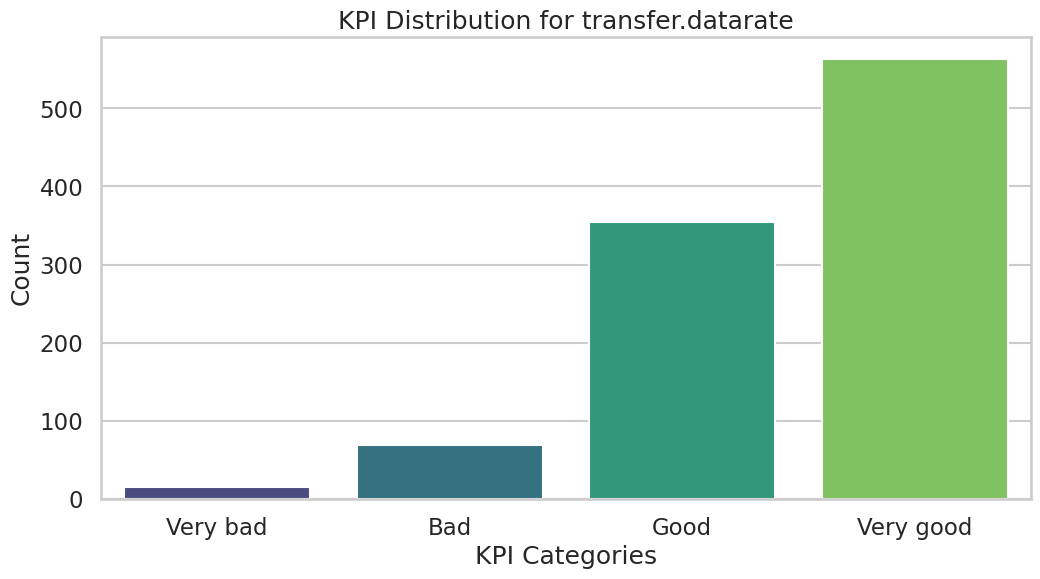

KPI category distribution after outlier removal:
Very bad: 15 samples
Bad: 69 samples
Good: 354 samples
Very good: 563 samples


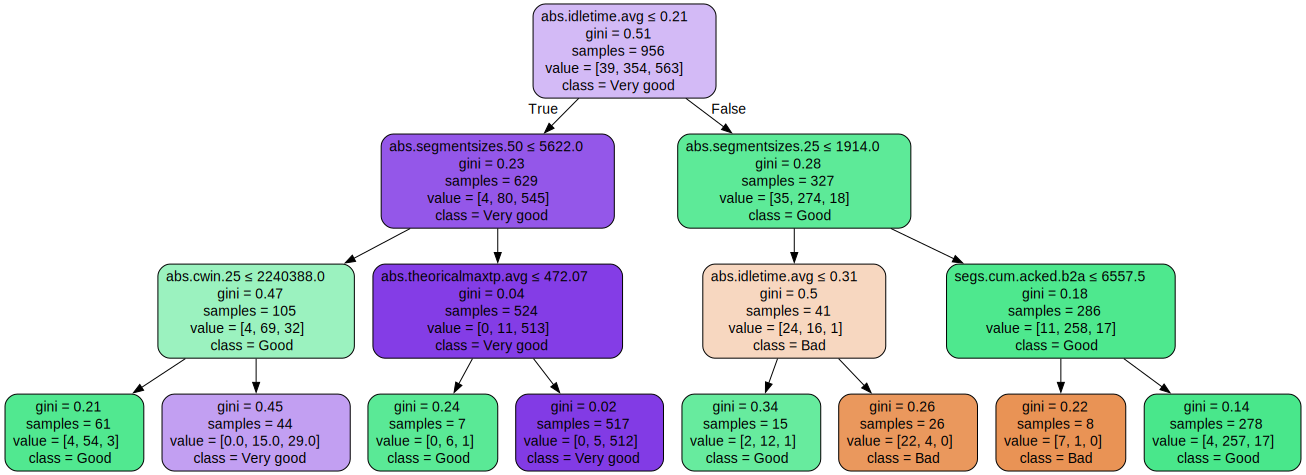

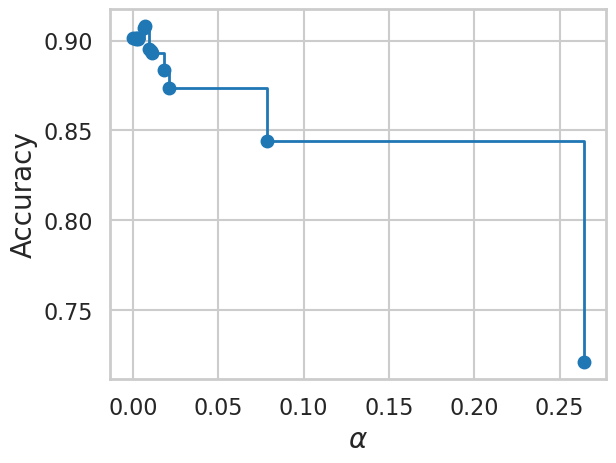

In [13]:
# -------------------------------------------------------------------
# KPI selection
# -------------------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier


target_kpi = 'transfer.datarate'
kpi_aux = data[target_kpi]
kpi_aux_log = np.log10(kpi_aux)
# -------------------------------------------------------------------
n_bins  = int(np.log2(len(kpi_aux_log))/2)
discretization_model = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans').fit(kpi_aux_log.values.reshape(-1, 1))
yd = discretization_model.transform(kpi_aux_log.values.reshape(-1, 1))[:,0]
val, count = np.unique(yd, return_counts=True)
labels = ['Very bad', 'Bad', 'Good', 'Very good']

plt.figure(figsize=(12, 6))
sns.barplot(x=val, y=count, palette='viridis')
plt.xticks(ticks=val, labels=labels)
plt.xlabel('KPI Categories')
plt.ylabel('Count')
plt.title(f'KPI Distribution for {target_kpi}')
plt.show()

mask = detect_outliers_mad(kpi_aux_log)
mask = ~mask  # Invert mask to keep non-outliers

X_train = data.loc[mask, data.columns != target_kpi].values
y_train = data.loc[mask, target_kpi].values
Xcols = data.columns[data.columns != target_kpi]

vl, cnts = np.unique(yd, return_counts=True)
print("KPI category distribution after outlier removal:")
for category, count in zip(labels, cnts):
    print(f"{category}: {count} samples")
knowledge, scores, ccp_alphas, best_alpha = build_decision_tree(n_bins, 5, X_train, yd[mask], np.min(cnts))  
plot_pruning(ccp_alphas, scores)

bins = discretization_model.bin_edges_[0].tolist()
data1= pd.cut(x=kpi_aux_log[mask], bins = bins, labels=labels[0:val.shape[0]], include_lowest=True)
knowledge_label = DecisionTreeClassifier(max_depth=n_bins, min_samples_leaf=5, ccp_alpha=best_alpha)
knowledge_label.fit(X_train, data1)

dot_data = tree.export_graphviz(knowledge_label, 
                                feature_names = np.array(Xcols), 
                                class_names=knowledge_label.classes_, 
                                filled=True, 
                                rounded=True, 
                                out_file=None,
                                precision=2,
                                special_characters=True)

graph = graphviz.Source(dot_data)
graph.format='png'
#graph.format='svg'
# filename = graph.render(filename='models/monroe_dataset/model1_file_dl')
graph

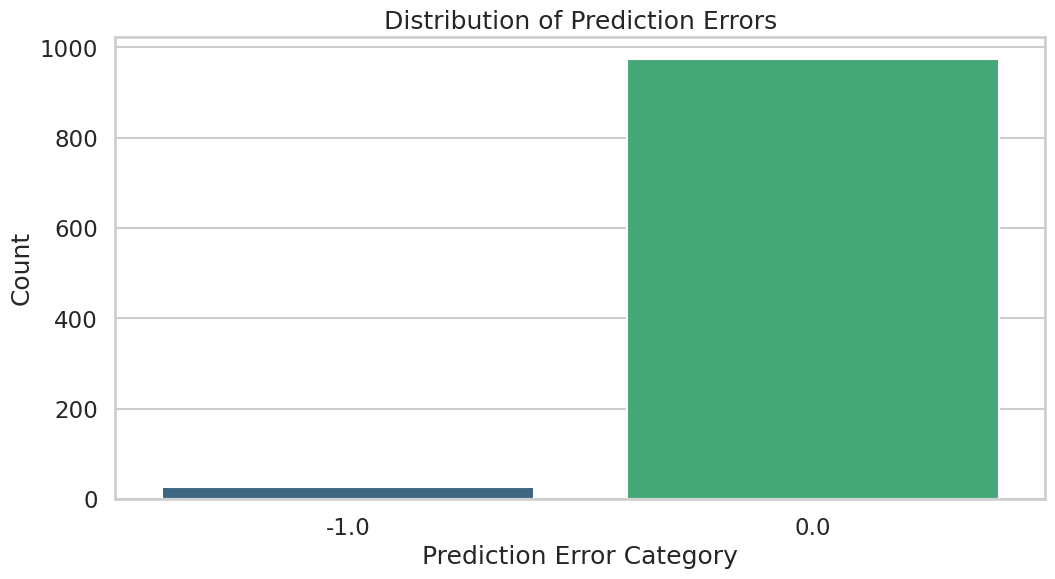

In [14]:
y_pred = knowledge.predict(data.loc[:, data.columns != target_kpi].values)
y_diff = y_pred - yd
y_diff[y_diff > 0] = 0
data["Diff_Pred"] = y_diff
val, count = np.unique(y_diff, return_counts=True)
plt.figure(figsize=(12, 6))
sns.barplot(x=val, y=count, palette='viridis')
# plt.xticks(ticks=val, labels=['Correct or Overestimated', 'Underestimated'])
plt.xlabel('Prediction Error Category')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.show()

## 7. Learning the Normal Behaviour Using a Regression Model

This cell builds a **residual-based anomaly-detection baseline**.

The workflow is:

1. apply the **MAD rule** to the log-transformed target KPI in order to identify a subset of samples considered *normal*,
2. keep only those non-anomalous samples for model fitting,
3. define the input matrix `X_train` using the explanatory features only,
4. define the response variable `y_train` as the `log10`-transformed throughput,
5. tune an **XGBoost regressor** with `RandomizedSearchCV`.

The purpose of this step is to learn the expected KPI behaviour under normal operating conditions.  
Later, anomalous behaviour can be investigated through the mismatch between the **observed KPI** and the **predicted KPI**. This approach is different from direct outlier detection methods such as One-Class SVM, Isolation Forest, or LOF.  
Here, anomalies are interpreted as **large prediction errors** with respect to a model of normal network behaviour.


In [ ]:
RANDOM_STATE = 42

mask = detect_outliers_mad(kpi_aux_log)
mask = ~mask  # Invert mask to keep non-outliers

Xcols = data.columns[data.columns != target_kpi]  # Redefine to ensure consistency
X_train = data.loc[mask, data.columns != target_kpi].values
y_train = data.loc[mask, target_kpi].values

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.6}


### Evaluating predictive fit and visualizing candidate anomalies

This cell evaluates the fitted XGBoost model and visualizes its predictions.

- **MSE**, **RMSE**, **MAE**, and **R²** are computed on the training subset.
- The first scatter plot compares **actual** versus **predicted** `log10` throughput for the normal samples used during training.
- The second scatter plot overlays:
  - the training subset labeled as **Normal**
  - the previously filtered samples labeled as **Anomaly**

The red dashed line represents the ideal case in which prediction and observation coincide exactly.

### How to interpret the plots

- Points close to the diagonal indicate that the model explains the KPI well.
- Large deviations from the diagonal correspond to observations whose throughput is not consistent with the learned normal-behaviour model.
- In a residual-based anomaly detector, these deviations can be converted into an **anomaly score** and thresholded to produce final anomaly labels.


Training Metrics:
MSE: 90610166.7625
RMSE: 9518.9373
MAE: 7388.7093
R²: 0.9974


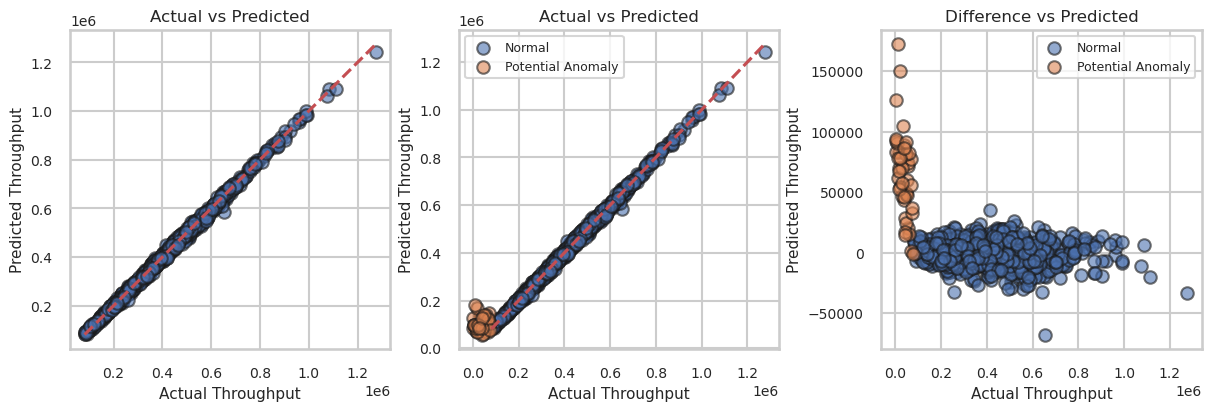

In [16]:
# Evaluate on training data
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"\nTraining Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

X_test = data.loc[~mask, data.columns != target_kpi].values
y_test = data.loc[~mask, target_kpi].values
y_test_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

axes[0].scatter(y_train, y_pred, alpha=0.6, edgecolor='k')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel("Actual Throughput", fontsize=11)
axes[0].set_ylabel("Predicted Throughput", fontsize=11)
axes[0].set_title("Actual vs Predicted", fontsize=12) 
axes[0].tick_params(axis="both", labelsize=10)
plt.gca().xaxis.get_offset_text().set_fontsize(10)
# plt.gca().yaxis.get_offset_text().set_fontsize(10)

axes[1].scatter(y_train, y_pred, alpha=0.6, edgecolor='k', label="Normal")
axes[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolor='k', label="Potential Anomaly")
axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[1].set_xlabel("Actual Throughput", fontsize=11)
axes[1].set_ylabel("Predicted Throughput", fontsize=11)
axes[1].set_title("Actual vs Predicted", fontsize=12)
axes[1].tick_params(axis="both", labelsize=10) 
axes[1].legend(fontsize=9)

axes[2].scatter(y_train, y_pred - y_train, alpha=0.6, edgecolor='k', label="Normal")
axes[2].scatter(y_test, y_test_pred - y_test, alpha=0.6, edgecolor='k', label="Potential Anomaly")
axes[2].set_xlabel("Actual Throughput", fontsize=11)
axes[2].set_ylabel("Predicted Throughput", fontsize=11)
axes[2].set_title("Difference vs Predicted", fontsize=12)
axes[2].tick_params(axis="both", labelsize=10) 
axes[2].legend(fontsize=9)

# Force creation of offset texts like "1e6"
fig.canvas.draw()

# Change fontsize of the scientific-notation offset text
for ax in axes:
    ax.xaxis.get_offset_text().set_fontsize(10)
    ax.yaxis.get_offset_text().set_fontsize(10)
plt.show()

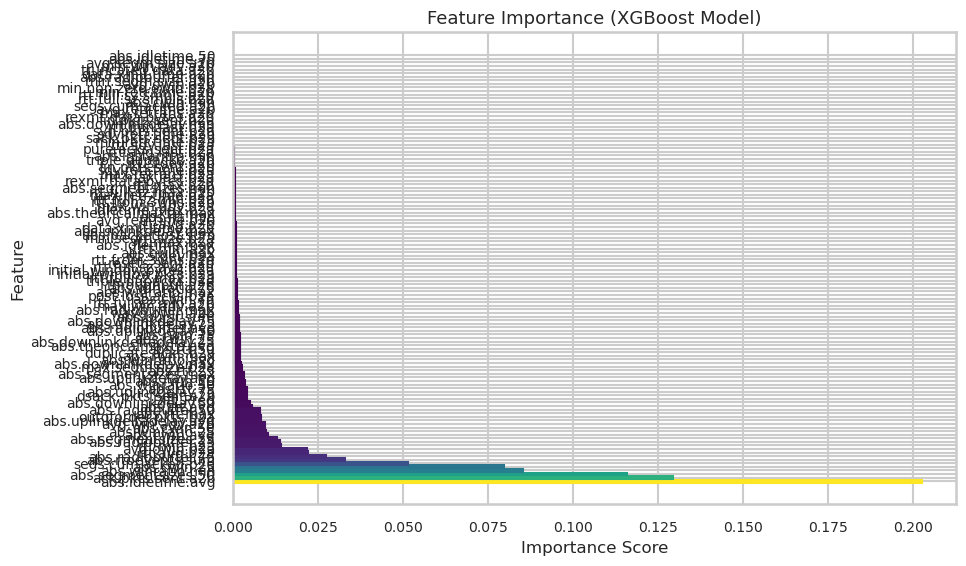


Top 10 Most Important Features:
            Feature  Importance
   abs.idletime.avg    0.202477
  ack.pkts.sent.a2b    0.129302
abs.segmentsizes.50    0.115854
   abs.winratio.min    0.085478
        abs.cwin.25    0.079636
 segs.cum.acked.b2a    0.051589
  abs.rtoevents.sum    0.033140
 abs.radiobuffer.75    0.027348
        rtt.avg.b2a    0.022094
       avg.owin.b2a    0.021803


In [17]:

# Extract feature importances
feature_names = np.array(data.columns[data.columns != target_kpi])
importances = best_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], edgecolor='black')

# Color bars by importance
colors = plt.cm.viridis(importance_df['Importance'] / importance_df['Importance'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance (XGBoost Model)', fontsize=13)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))


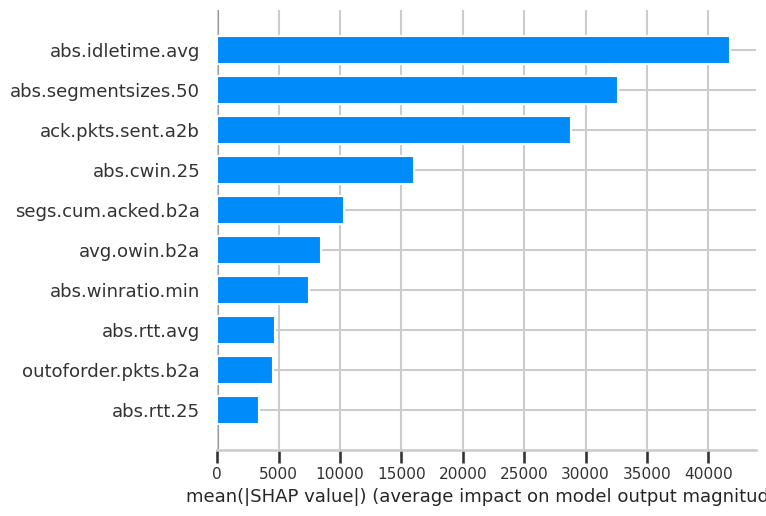

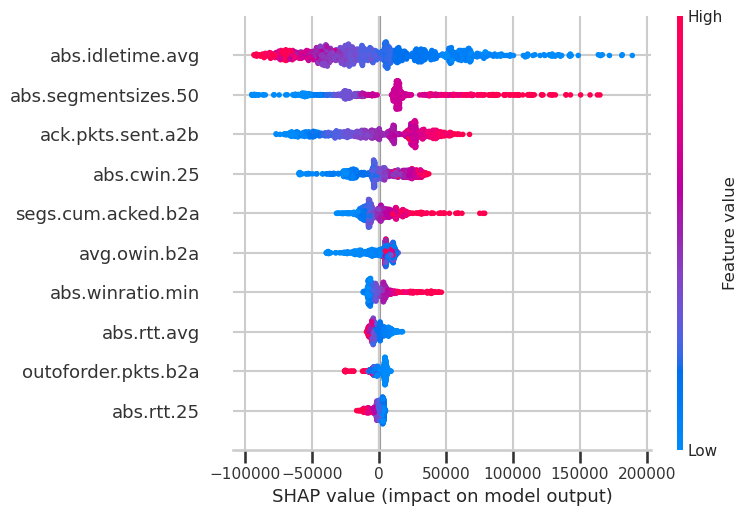

In [18]:
import shap

explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, features=X_train, feature_names=feature_names, plot_type="bar", max_display=10)
shap.summary_plot(shap_values, features=X_train, feature_names=feature_names, plot_type="dot", max_display=10)


In [30]:
from lime.lime_tabular import LimeTabularExplainer

# Create LIME explainer for regression
explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=Xcols.to_list(),
    mode='regression',
    random_state=RANDOM_STATE
)

# Choose a sample to explain (let's use the first anomalous sample)
sample_idx = 0  # Index of the sample to explain
sample_to_explain = X_test[sample_idx].reshape(1, -1)
actual_value = y_test[sample_idx]
predicted_value = y_test_pred[sample_idx]

print(f"Explaining sample {sample_idx}:")
print(f"Actual throughput: {actual_value:.4f}")
print(f"Predicted throughput: {predicted_value:.4f}")
print(f"Prediction error: {abs(actual_value - predicted_value):.4f}")

# Generate explanation
exp = explainer.explain_instance(
    data_row=sample_to_explain[0],
    predict_fn=best_model.predict,
    num_features=10  # Show top 10 features
)

# Plot the explanation
fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation for Sample {sample_idx}\n(Predicted: {predicted_value:.4f}, Actual: {actual_value:.4f})')
plt.tight_layout()
plt.show()

# Print the explanation details
print("\nFeature contributions:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

IndexError: list index out of range